<a href="https://colab.research.google.com/github/Aditipujari10/Deep_Learning_Lab/blob/main/DL_EXP_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9187 - loss: 0.2759 - val_accuracy: 0.9582 - val_loss: 0.1450
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9660 - loss: 0.1141 - val_accuracy: 0.9634 - val_loss: 0.1100
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9752 - loss: 0.0805 - val_accuracy: 0.9699 - val_loss: 0.1021
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9809 - loss: 0.0598 - val_accuracy: 0.9709 - val_loss: 0.1011
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9847 - loss: 0.0471 - val_accuracy: 0.9759 - val_loss: 0.0870
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9880 - loss: 0.0373 - val_accuracy: 0.9725 - val_loss: 0.0929
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9905 - loss: 0.0299 - val_accuracy: 0.9743 - val_loss: 0.0991
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9909 - loss: 0.0268 -

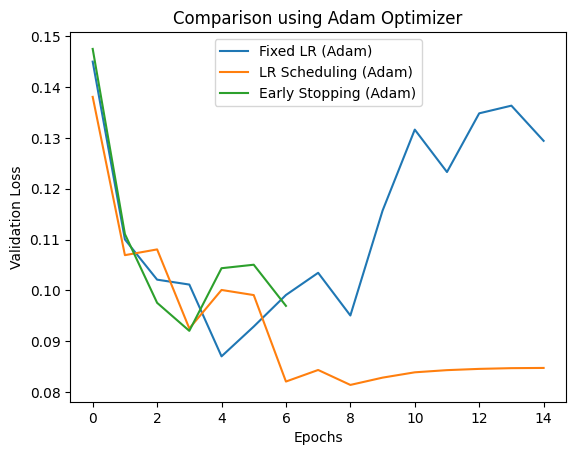

In [ ]:
# Import required libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0


def create_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),   # 28x28 → 784
        layers.Dense(128, activation='relu'),   # Hidden layer 1
        layers.Dense(64, activation='relu'),    # Hidden layer 2
        layers.Dense(10, activation='softmax')  # Output layer
    ])
    return model


model_fixed = create_model()

model_fixed.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),  # Fixed LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fixed = model_fixed.fit(
    x_train, y_train,
    epochs=15,
    validation_split=0.2
)



# Define scheduler function
def lr_scheduler(epoch, lr):
    if epoch > 5:
        return lr * 0.5   # Reduce LR after 5 epochs
    return lr

lr_callback = keras.callbacks.LearningRateScheduler(lr_scheduler)

model_sched = create_model()

model_sched.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sched = model_sched.fit(
    x_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=[lr_callback]   # Apply scheduler
)



early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',       # Monitor validation loss
    patience=3,               # Stop if no improvement for 3 epochs
    restore_best_weights=True
)

model_early = create_model()

model_early.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_early = model_early.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop]   # Apply early stopping
)


plt.plot(history_fixed.history['val_loss'], label='Fixed LR (Adam)')
plt.plot(history_sched.history['val_loss'], label='LR Scheduling (Adam)')
plt.plot(history_early.history['val_loss'], label='Early Stopping (Adam)')

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("Comparison using Adam Optimizer")
plt.show()